Nama    : I Made Telaga Dwiraditya \
ID      : CDCC008D6Y2707 \
Kelas   : CDC-33

# *Import Library*

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from wordcloud import WordCloud
from collections import Counter
from datasets import load_dataset

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# *Data Wragling*

## *Gather Dataset*

In [34]:
# Dataset 1: dair-ai/emotion
print("\n[1/14] Mengunduh dair-ai/emotion...")
try:
    ds_emotion = load_dataset("dair-ai/emotion", "unsplit", split="train")
except ValueError:
    ds_emotion = load_dataset("dair-ai/emotion", split="train")

df_emotion           = ds_emotion.to_pandas()[["text"]]
df_emotion["source"] = "dair-ai/emotion"

# Dataset 2: google-research-datasets/go_emotions
print("[2/14] Mengunduh google-research-datasets/go_emotions...")
ds_go            = load_dataset("google-research-datasets/go_emotions", "simplified", split="train")
df_go            = ds_go.to_pandas()[["text"]]
df_go["source"]  = "go_emotions"

# Dataset 3: mrm8488/go_emotions-es-mt (train + test + validation)
print("[3/14] Mengunduh mrm8488/go_emotions-es-mt...")
ds_go_es_train = load_dataset("mrm8488/go_emotions-es-mt", split="train")
ds_go_es_test  = load_dataset("mrm8488/go_emotions-es-mt", split="test")
ds_go_es_val   = load_dataset("mrm8488/go_emotions-es-mt", split="validation")
df_go_es = pd.concat([
    ds_go_es_train.to_pandas()[["text"]],
    ds_go_es_test.to_pandas()[["text"]],
    ds_go_es_val.to_pandas()[["text"]],
], ignore_index=True)
df_go_es["source"] = "go_emotions_es_mt"

# Dataset 4: noob123/emotion_augment (train + test)
print("[4/14] Mengunduh noob123/emotion_augment...")
ds_aug_train = load_dataset("noob123/emotion_augment", split="train")
ds_aug_test  = load_dataset("noob123/emotion_augment", split="test")
df_aug = pd.concat([
    ds_aug_train.to_pandas()[["text"]],
    ds_aug_test.to_pandas()[["text"]],
], ignore_index=True)
df_aug["source"] = "emotion_augment"

# Dataset 5: RikoteMaster/Emotion_Recognition_4_llama2 (train)
print("[5/14] Mengunduh RikoteMaster/Emotion_Recognition_4_llama2...")
ds_llama            = load_dataset("RikoteMaster/Emotion_Recognition_4_llama2", split="train", verification_mode = "no_checks")
df_llama            = ds_llama.to_pandas()[["Text_processed"]].rename(columns={"Text_processed": "text"})
df_llama["source"]  = "emotion_recognition_llama2"

# Dataset 6: Villian7/Emotions_Data (train + test + validation)
print("[6/14] Mengunduh Villian7/Emotions_Data...")
ds_vil_train = load_dataset("Villian7/Emotions_Data", split="train")
ds_vil_test  = load_dataset("Villian7/Emotions_Data", split="test")
ds_vil_val   = load_dataset("Villian7/Emotions_Data", split="validation")
df_vil = pd.concat([
    ds_vil_train.to_pandas()[["text"]],
    ds_vil_test.to_pandas()[["text"]],
    ds_vil_val.to_pandas()[["text"]],
], ignore_index=True)
df_vil["source"] = "emotions_data"

# Dataset 7: krishan-CSE/Unified_Dataset_with_Emotions (train + test + validation)
print("[7/14] Mengunduh krishan-CSE/Unified_Dataset_with_Emotions...")
ds_unified_train = load_dataset("krishan-CSE/Unified_Dataset_with_Emotions", split="train")
ds_unified_test  = load_dataset("krishan-CSE/Unified_Dataset_with_Emotions", split="test")
ds_unified_val   = load_dataset("krishan-CSE/Unified_Dataset_with_Emotions", split="validation")
df_unified = pd.concat([
    ds_unified_train.to_pandas()[["text"]],
    ds_unified_test.to_pandas()[["text"]],
    ds_unified_val.to_pandas()[["text"]],
], ignore_index=True)
df_unified["source"] = "unified_dataset_emotions"

# Dataset 8: Paul-HF/emotions (train + test + validation)
print("[8/14] Mengunduh Paul-HF/emotions...")
ds_paul_train = load_dataset("Paul-HF/emotions", split="train")
ds_paul_test  = load_dataset("Paul-HF/emotions", split="test")
ds_paul_val   = load_dataset("Paul-HF/emotions", split="validation")
df_paul = pd.concat([
    ds_paul_train.to_pandas()[["text"]],
    ds_paul_test.to_pandas()[["text"]],
    ds_paul_val.to_pandas()[["text"]],
], ignore_index=True)
df_paul["source"] = "paul_emotions"

# Dataset 9: sebdg/go_emotions (train + test)
print("[9/14] Mengunduh sebdg/go_emotions...")
ds_sebdg_train = load_dataset("sebdg/go_emotions", split="train")
ds_sebdg_test  = load_dataset("sebdg/go_emotions", split="test")
df_sebdg = pd.concat([
    ds_sebdg_train.to_pandas()[["text"]],
    ds_sebdg_test.to_pandas()[["text"]],
], ignore_index=True)
df_sebdg["source"] = "sebdg_go_emotions"

# Dataset 10: cirimus/super-emotion (train + test + validation)
print("[10/14] Mengunduh cirimus/super-emotion...")
ds_super_train = load_dataset("cirimus/super-emotion", split="train")
ds_super_test  = load_dataset("cirimus/super-emotion", split="test")
ds_super_val   = load_dataset("cirimus/super-emotion", split="validation")
df_super = pd.concat([
    ds_super_train.to_pandas()[["text"]],
    ds_super_test.to_pandas()[["text"]],
    ds_super_val.to_pandas()[["text"]],
], ignore_index=True)
df_super["source"] = "super_emotion"

# Dataset 11: amineouaki/emotion_englishv (train + test + validation)
print("[11/14] Mengunduh amineouaki/emotion_englishv...")
ds_eng1_train = load_dataset("amineouaki/emotion_englishv", split="train")
ds_eng1_test  = load_dataset("amineouaki/emotion_englishv", split="test")
ds_eng1_val   = load_dataset("amineouaki/emotion_englishv", split="validation")
df_eng1 = pd.concat([
    ds_eng1_train.to_pandas()[["Text"]].rename(columns={"Text": "text"}),
    ds_eng1_test.to_pandas()[["Text"]].rename(columns={"Text": "text"}),
    ds_eng1_val.to_pandas()[["Text"]].rename(columns={"Text": "text"}),
], ignore_index=True)
df_eng1["source"] = "emotion_englishv"

# Dataset 12: amineouaki/emotion_englishv2 (train + test + validation)
print("[12/14] Mengunduh amineouaki/emotion_englishv2...")
ds_eng2_train = load_dataset("amineouaki/emotion_englishv2", split="train")
ds_eng2_test  = load_dataset("amineouaki/emotion_englishv2", split="test")
ds_eng2_val   = load_dataset("amineouaki/emotion_englishv2", split="validation")
df_eng2 = pd.concat([
    ds_eng2_train.to_pandas()[["Text"]].rename(columns={"Text": "text"}),
    ds_eng2_test.to_pandas()[["Text"]].rename(columns={"Text": "text"}),
    ds_eng2_val.to_pandas()[["Text"]].rename(columns={"Text": "text"}),
], ignore_index=True)
df_eng2["source"] = "emotion_englishv2"

# Dataset 13: boltuix/emotions-dataset (train)
print("[13/14] Mengunduh boltuix/emotions-dataset...")
ds_boltuix           = load_dataset("boltuix/emotions-dataset", split="train")
df_boltuix           = ds_boltuix.to_pandas()[["Sentence"]].rename(columns={"Sentence": "text"})
df_boltuix["source"] = "boltuix_emotions"

# Dataset 14: Alegzandra/REDv2_gpt-40-mini-emotion-prompt (train + test + validation)
print("[14/14] Mengunduh Alegzandra/REDv2_gpt-40-mini-emotion-prompt...")
ds_red_train = load_dataset("Alegzandra/REDv2_gpt-40-mini-emotion-prompt", split="train")
ds_red_test  = load_dataset("Alegzandra/REDv2_gpt-40-mini-emotion-prompt", split="test")
ds_red_val   = load_dataset("Alegzandra/REDv2_gpt-40-mini-emotion-prompt", split="validation")
df_red = pd.concat([
    ds_red_train.to_pandas()[["text"]],
    ds_red_test.to_pandas()[["text"]],
    ds_red_val.to_pandas()[["text"]],
], ignore_index=True)
df_red["source"] = "redv2_emotion"

# Merge semua dataset
df_raw = pd.concat([
    df_emotion,
    df_go,
    df_go_es,
    df_aug,
    df_llama,
    df_vil,
    df_unified,
    df_paul,
    df_sebdg,
    df_super,
    df_eng1,
    df_eng2,
    df_boltuix,
    df_red
], ignore_index=True)

print(f"\nTotal data mentah : {len(df_raw):,} baris")
print(f"Kolom             : {list(df_raw.columns)}")
print("\nSample data:")
print(df_raw.head(5).to_string(index=False))


[1/14] Mengunduh dair-ai/emotion...
[2/14] Mengunduh google-research-datasets/go_emotions...
[3/14] Mengunduh mrm8488/go_emotions-es-mt...
[4/14] Mengunduh noob123/emotion_augment...
[5/14] Mengunduh RikoteMaster/Emotion_Recognition_4_llama2...
[6/14] Mengunduh Villian7/Emotions_Data...
[7/14] Mengunduh krishan-CSE/Unified_Dataset_with_Emotions...
[8/14] Mengunduh Paul-HF/emotions...
[9/14] Mengunduh sebdg/go_emotions...
[10/14] Mengunduh cirimus/super-emotion...
[11/14] Mengunduh amineouaki/emotion_englishv...
[12/14] Mengunduh amineouaki/emotion_englishv2...
[13/14] Mengunduh boltuix/emotions-dataset...


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\datasets--boltuix--emotions-dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split:

[14/14] Mengunduh Alegzandra/REDv2_gpt-40-mini-emotion-prompt...


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\datasets--Alegzandra--REDv2_gpt-40-mini-emotion-prompt. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Gene


Total data mentah : 3,630,113 baris
Kolom             : ['text', 'source']

Sample data:
                                                                                                                                                    text          source
                                        i feel awful about it too because it s my job to get him in a position to succeed and it just didn t happen here dair-ai/emotion
                                                                                                                                   im alone i feel awful dair-ai/emotion
ive probably mentioned this before but i really do feel proud of myself for actually keeping up with my new years resolution of monthly and weekly goals dair-ai/emotion
                                                                                                                i was feeling a little low few days back dair-ai/emotion
                                                     i beleive th

## *Assessing Dataset*

In [35]:
# --- Missing value ---
print("\n[ Missing Value ]")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    "jumlah_missing" : missing,
    "persentase (%)" : missing_pct
})
print(missing_df)

# --- Duplikat ---
print("\n[ Duplikat ]")
n_dup = df_raw.duplicated(subset=["text"]).sum()
print(f"Jumlah baris duplikat : {n_dup:,}")
print(f"Persentase duplikat   : {n_dup / len(df_raw) * 100:.2f}%")

# --- Info umum ---
print("\n[ Info Umum ]")
print(f"Distribusi sumber data:")
print(df_raw["source"].value_counts().to_string())


[ Missing Value ]
        jumlah_missing  persentase (%)
text                 0             0.0
source               0             0.0

[ Duplikat ]
Jumlah baris duplikat : 1,630,174
Persentase duplikat   : 44.91%

[ Info Umum ]
Distribusi sumber data:
source
emotions_data                 1363078
super_emotion                  552821
paul_emotions                  416809
dair-ai/emotion                416809
emotion_augment                239348
sebdg_go_emotions              211214
boltuix_emotions               131306
emotion_recognition_llama2     122926
go_emotions_es_mt               54263
go_emotions                     43410
unified_dataset_emotions        42905
emotion_englishv2               16714
emotion_englishv                13061
redv2_emotion                    5449


## *Cleaning Dataset*

### Hapus Duplikat

In [36]:
# Hapus missing value & duplikat
print("\n[i] Menghapus duplikat...")

df_clean = df_raw.drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"Sebelum : {len(df_raw):} baris")
print(f"Sesudah : {len(df_clean):} baris")
print(f"Dihapus : {len(df_raw) - len(df_clean):} baris")


[i] Menghapus duplikat...
Sebelum : 3630113 baris
Sesudah : 1999939 baris
Dihapus : 1630174 baris


### *Cleaning Text*

In [37]:
# Cleaning Text & Expand contractions
contractions_dict = {
    # I (dengan apostrof)
    "i'm"       : "i am",
    "i've"      : "i have",
    "i'll"      : "i will",
    "i'd"       : "i would",
    # I (tanpa apostrof — typo/informal)
    "im"        : "i am",
    "ive"       : "i have",
    #"ill"       : "i will",   # hati-hati: "ill" juga berarti sakit
    #"id"        : "i would",  # hati-hati: "id" juga bisa noun
    # you
    "you're"    : "you are",
    "you've"    : "you have",
    "you'll"    : "you will",
    "you'd"     : "you would",
    "youre"     : "you are",
    "youve"     : "you have",
    "youll"     : "you will",
    "youd"      : "you would",
    # he
    "he's"      : "he is",
    "he'll"     : "he will",
    "he'd"      : "he would",
    "hes"       : "he is",
    "hed"       : "he would",
    # she
    "she's"     : "she is",
    "she'll"    : "she will",
    "she'd"     : "she would",
    "shes"      : "she is",
    "shed"      : "she would",
    # it
    "it's"      : "it is",
    "it'll"     : "it will",
    "it'd"      : "it would",
    #"its"       : "it is",    # hati-hati: "its" juga bisa possessive
    # we
    "we're"     : "we are",
    "we've"     : "we have",
    "we'll"     : "we will",
    "we'd"      : "we would",
    #"were"      : "we are",   # hati-hati: "were" juga past tense "be"
    "weve"      : "we have",
    "wed"       : "we would",
    # they
    "they're"   : "they are",
    "they've"   : "they have",
    "they'll"   : "they will",
    "they'd"    : "they would",
    "theyre"    : "they are",
    "theyve"    : "they have",
    "theyll"    : "they will",
    "theyd"     : "they would",
    # negations (dengan apostrof)
    "aren't"    : "are not",
    "isn't"     : "is not",
    "wasn't"    : "was not",
    "weren't"   : "were not",
    "don't"     : "do not",
    "doesn't"   : "does not",
    "didn't"    : "did not",
    "won't"     : "will not",
    "wouldn't"  : "would not",
    "can't"     : "can not",
    "cannot"    : "can not",
    "couldn't"  : "could not",
    "shouldn't" : "should not",
    "hadn't"    : "had not",
    "hasn't"    : "has not",
    "haven't"   : "have not",
    "mustn't"   : "must not",
    "needn't"   : "need not",
    "daren't"   : "dare not",
    "shan't"    : "shall not",
    # negations (tanpa apostrof — typo/informal)
    "arent"     : "are not",
    "isnt"      : "is not",
    "wasnt"     : "was not",
    "werent"    : "were not",
    "dont"      : "do not",
    "doesnt"    : "does not",
    "didnt"     : "did not",
    "wont"      : "will not",
    "wouldnt"   : "would not",
    "cant"      : "can not",
    "couldnt"   : "could not",
    "shouldnt"  : "should not",
    "hadnt"     : "had not",
    "hasnt"     : "has not",
    "havent"    : "have not",
    "mustnt"    : "must not",
    # have/would combinations (dengan apostrof)
    "that've"   : "that have",
    "who've"    : "who have",
    "would've"  : "would have",
    "could've"  : "could have",
    "should've" : "should have",
    "might've"  : "might have",
    "must've"   : "must have",
    # have/would combinations (tanpa apostrof)
    "wouldve"   : "would have",
    "couldve"   : "could have",
    "shouldve"  : "should have",
    "mightve"   : "might have",
    "mustve"    : "must have",
    # misc (dengan apostrof)
    "that's"    : "that is",
    "that'd"    : "that would",
    "there's"   : "there is",
    "there're"  : "there are",
    "there'll"  : "there will",
    "who's"     : "who is",
    "who'd"     : "who would",
    "who'll"    : "who will",
    "what's"    : "what is",
    "what're"   : "what are",
    "what'll"   : "what will",
    "what'd"    : "what did",
    "where's"   : "where is",
    "where'd"   : "where did",
    "when's"    : "when is",
    "why's"     : "why is",
    "how's"     : "how is",
    "how'd"     : "how did",
    "how'll"    : "how will",
    "let's"     : "let us",
    "y'all"     : "you all",
    # misc (tanpa apostrof)
    "thats"     : "that is",
    "theres"    : "there is",
    "whos"      : "who is",
    "whats"     : "what is",
    "wheres"    : "where is",
    "whens"     : "when is",
    "whys"      : "why is",
    "hows"      : "how is",
    "lets"      : "let us",
    "yall"      : "you all",
    # informal/slang
    "gonna"     : "going to",
    "wanna"     : "want to",
    "gotta"     : "got to",
    "kinda"     : "kind of",
    "sorta"     : "sort of",
    "dunno"     : "do not know",
    "ain't"     : "is not",
    "aint"      : "is not",
    "tryna"     : "trying to",
    "hafta"     : "have to",
    "oughta"    : "ought to",
    "supposta"  : "supposed to",
    "useta"     : "used to",
}

contractions_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in contractions_dict.keys()) + r')\b',
    re.IGNORECASE
)

def expand_contractions(text):
    def replace(match):
        token = match.group(0).lower()
        return contractions_dict.get(token, token)
    return contractions_pattern.sub(replace, text)


In [38]:
def clean_text_v1(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # hapus URL
    text = expand_contractions(text)               # expand contractions
    text = re.sub(r"[^a-zA-Z\s]", " ", text)      # hapus karakter non-huruf
    text = re.sub(r"\s+", " ", text).strip()       # rapikan spasi
    return text

def clean_text_v2(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # hapus URL
    text = expand_contractions(text)               # expand contractions
    text = re.sub(r"[^\w\s]", " ", text)          # hapus tanda baca
    text = re.sub(r"[^a-zA-Z\s]", " ", text)      # hapus karakter non-huruf
    text = re.sub(r"\s+", " ", text).strip()       # rapikan spasi
    return text

print("\n[ii] Cleaning teks...")
df_clean["input_clean"] = df_clean["text"].apply(clean_text_v1)   # tanpa hapus tanda baca
df_clean["input_no_punct"] = df_clean["text"].apply(clean_text_v2)   # dengan hapus tanda baca


[ii] Cleaning teks...


### *Filtering (Breakup Score)*

In [39]:
# Filter breakup score
breakup_keywords = [
    # RELATIONSHIP TERMS
    "boyfriend", "girlfriend", "bf", "gf", "partner",
    "husband", "wife", "fiance", "fiancee",
    "lover", "significant other", "spouse",
    "crush", "dating", "relationship",
    "romantic relationship", "long distance relationship",
    "ldr", "situationship",
    # BREAKUP TERMS
    "breakup", "break up", "broke up", "broken up",
    "split up", "ended things", "ended our relationship",
    "ended our friendship", "called it quits",
    "dumped", "got dumped", "left me", "left him",
    "left her", "walked away", "abandoned me",
    "moved on", "moving on", "separated",
    "divorce", "divorced", "separation",
    # EX / PAST RELATIONSHIP
    "my ex", "ex boyfriend", "ex girlfriend",
    "former boyfriend", "former girlfriend",
    "past relationship", "past lover",
    "previous relationship",
    # HEARTBREAK / LOSS
    "heartbroken", "broken heart", "hurt",
    "hurt me", "emotionally hurt",
    "devastated", "shattered", "crushed",
    "betrayed", "abandoned", "rejected",
    "unloved", "unwanted", "lonely",
    "miss him", "miss her", "miss my ex",
    "can not forget", "still love", "still miss",
    "lost him", "lost her", "can not move on",
    "crying over", "thinking about my ex",
    "thinking about him", "thinking about her",
    # CHEATING / BETRAYAL
    "cheated", "cheating", "affair",
    "unfaithful", "lied to me",
    "betrayed my trust", "two timed",
    "seeing someone else",
    "talking to another girl",
    "talking to another guy",
    # TOXIC RELATIONSHIP
    "toxic relationship", "manipulative",
    "emotionally abusive", "gaslight",
    "gaslighting", "controlling",
    "possessive", "ignored me",
    "ghosted", "blocked me",
    "silent treatment", "red flag",
    "used me", "took advantage of me",
    # ARGUMENT / CONFLICT
    "argument", "argued", "fight",
    "fighting", "fight with my boyfriend",
    "fight with my girlfriend",
    "constant fighting", "we fought",
    "we keep arguing", "misunderstanding",
    "conflict in relationship",
    # ANXIETY AFTER BREAKUP
    "overthinking him", "overthinking her",
    "anxious about relationship",
    "relationship anxiety", "fear of losing",
    "afraid to lose him", "afraid to lose her",
    "worried he will leave", "worried she will leave",
    "attachment issues", "clingy", "insecure relationship",
    # ACCEPTANCE / HEALING
    "healing", "recovering", "trying to move on",
    "self love", "letting go", "finding peace", "closure",
    "finally okay", "feeling better", "accepting the breakup",
    "learning to be alone", "working on myself",
    "focusing on myself", "becoming independent",
    # SOCIAL MEDIA / MODERN TERMS
    "seen zoned", "friend zoned", "unfollowed me",
    "blocked me", "removed me", "texted my ex",
    "stalk my ex", "checking his profile", "checking her profile",
    # COMMON EXPRESSIONS
    "he does not love me", "she does not love me",
    "he stopped talking to me", "she stopped talking to me",
    "he lost feelings", "she lost feelings",
    "i miss my relationship", "i feel alone after breakup",
    "i can not stop thinking about him",
    "i can not stop thinking about her",
    "i want him back", "i want her back",
    "i still care about him", "i still care about her"
]

breakup_anger_keywords = [
    "cheated", "cheating", "affair", "unfaithful", "lied to me",
    "betrayed", "betrayed my trust", "two timed", "manipulative",
    "gaslighting", "controlling", "toxic relationship", "emotionally abusive",
    "used me", "took advantage of me", "ghosted", "blocked me",
    "silent treatment", "red flag", "possessive", "ignored me",
    "argument", "argued", "fight", "fighting", "we fought",
    "constant fighting", "endless arguments"
]

breakup_anxiety_keywords = [
    "miss him", "miss her", "miss my ex", "still love", "still miss",
    "can not forget", "can not move on", "thinking about him",
    "thinking about her", "thinking about my ex", "i want him back",
    "i want her back", "i still care about him", "i still care about her",
    "overthinking him", "overthinking her", "relationship anxiety",
    "fear of losing", "afraid to lose him", "afraid to lose her",
    "worried he will leave", "worried she will leave",
    "attachment issues", "clingy", "insecure relationship",
    "heartbroken", "broken heart", "devastated", "shattered", "crushed",
    "lonely", "unloved", "unwanted", "lost him", "lost her",
    "crying over", "stalk my ex", "checking his profile", "checking her profile"
]

breakup_acceptance_keywords = [
    "healing", "recovering", "trying to move on", "self love",
    "letting go", "finding peace", "closure", "finally okay",
    "feeling better", "accepting the breakup", "learning to be alone",
    "working on myself", "focusing on myself", "becoming independent",
    "starting over", "fresh start", "new chapter", "new beginning",
    "getting over him", "getting over her", "slowly healing"
]

In [40]:
def get_breakup_score(text, keywords):
    text = str(text).lower()
    score = 0
    for keyword in keywords:
        pattern = r"\b" + re.escape(keyword.lower()) + r"\b"
        if re.search(pattern, text):
            score += 1
    return score

print("\n[iii] Menghitung breakup score...")
df_clean["breakup_score"] = df_clean["input_no_punct"].apply(
    lambda x: get_breakup_score(x, breakup_keywords)
)

df_filtered = df_clean[
    df_clean["breakup_score"] >= 2
].copy().reset_index(drop=True)

print(f"Sebelum filter : {len(df_clean):} baris")
print(f"Sesudah filter : {len(df_filtered):} baris")
print(f"Dihapus        : {len(df_clean) - len(df_filtered):} baris")


[iii] Menghitung breakup score...
Sebelum filter : 1999939 baris
Sesudah filter : 7277 baris
Dihapus        : 1992662 baris


# *EDA & Visualization*

## *Emotion Lexicon (Feature Engineering*)

In [43]:
# Dictionary
# bobot per kata: semakin kuat ekspresi emosi, semakin tinggi bobotnya
anger_words = {
    # bobot tinggi (ekspresi kuat)
    "furious"      : 3, "rage"         : 3, "livid"        : 3,
    "fuming"       : 3, "outrage"      : 3, "hate"         : 3,
    "loathe"       : 3, "despise"      : 3, "screamed"     : 3,
    "yelled"       : 3, "betrayed"     : 3, "manipulative" : 3,
    "gaslighting"  : 3, "abusive"      : 3, "narcissist"   : 3,
    # bobot sedang
    "angry"        : 2, "anger"        : 2, "bitter"       : 2,
    "resentful"    : 2, "frustrated"   : 2, "irritated"    : 2,
    "disgusted"    : 2, "cruel"        : 2, "heartless"    : 2,
    "toxic"        : 2, "controlling"  : 2, "lied"         : 2,
    "cheated"      : 2, "unfaithful"   : 2, "selfish"      : 2,
    # bobot rendah (ekspresi umum)
    "mad"          : 1, "upset"        : 1, "annoyed"      : 1,
    "piss"         : 1, "sick"         : 1, "done"         : 1,
    "fed"          : 1, "trigger"      : 1, "grudge"       : 1,
    "disappoint"   : 1, "resent"       : 1, "hurt"         : 1,
    "salty"        : 1, "used"         : 1, "disrespect"   : 1,
    "humiliate"    : 1, "betray"       : 1, "annoy"        : 1,
    "frustrate"    : 1, "fury"         : 1, "irritate"     : 1,
}

anxiety_words = {
    # bobot tinggi
    "terrified"    : 3, "panic"        : 3, "paranoid"     : 3,
    "desperate"    : 3, "hopeless"     : 3, "obsess"       : 3,
    "spiral"       : 3, "shattered"    : 3, "helpless"     : 3,
    "sleepless"    : 3, "dread"        : 3,
    # bobot sedang
    "anxious"      : 2, "anxiety"      : 2, "afraid"       : 2,
    "insecure"     : 2, "overthink"    : 2, "overwhelm"    : 2,
    "lonely"       : 2, "empty"        : 2, "numb"         : 2,
    "broken"       : 2, "lost"         : 2, "hollow"       : 2,
    "crying"       : 2, "weeping"      : 2, "tears"        : 2,
    "clingy"       : 2, "stalk"        : 2, "attachment"   : 2,
    # bobot rendah
    "worry"        : 1, "nervous"      : 1, "stress"       : 1,
    "restless"     : 1, "uneasy"       : 1, "unsure"       : 1,
    "confuse"      : 1, "doubt"        : 1, "hesitate"     : 1,
    "stuck"        : 1, "fear"         : 1, "worried"      : 1,
    "miss"         : 1, "still"        : 1, "forget"       : 1,
    "thinking"     : 1, "checking"     : 1, "cling"        : 1,
    "scare"        : 1,
}

acceptance_words = {
    # bobot tinggi
    "forgive"      : 3, "closure"      : 3, "rediscover"   : 3,
    "gratitude"    : 3, "grateful"     : 3, "unbothered"   : 3,
    "confident"    : 3, "proud"        : 3, "clarity"      : 3,
    # bobot sedang
    "accept"       : 2, "heal"         : 2, "peace"        : 2,
    "recover"      : 2, "independent"  : 2, "rebuild"      : 2,
    "forward"      : 2, "calm"         : 2, "free"         : 2,
    "growth"       : 2, "strong"       : 2, "release"      : 2,
    "relief"       : 2, "smile"        : 2, "happy"        : 2,
    "joy"          : 2, "comfortable"  : 2, "indifferent"  : 2,
    # bobot rendah
    "move"         : 1, "okay"         : 1, "realize"      : 1,
    "learn"        : 1, "better"       : 1, "start"        : 1,
    "understand"   : 1, "grow"         : 1, "enough"       : 1,
    "change"       : 1, "finally"      : 1, "letting"      : 1,
    "finding"      : 1, "feeling"      : 1, "accepting"    : 1,
    "working"      : 1, "focusing"     : 1, "becoming"     : 1,
    "laugh"        : 1,
}

emotion_dict = {
    "anger"      : anger_words,
    "anxiety"    : anxiety_words,
    "acceptance" : acceptance_words,
}

In [44]:
# Hitung probabilitas emosi
def preprocess_for_emotion(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

def detect_structure_emotion(text):
    text = str(text).lower()
    scores = {"anger": 0, "anxiety": 0, "acceptance": 0}

    # pola kalimat tanya → anxiety
    if re.search(r"\b(why|what if|how could|where did|when will)\b", text):
        scores["anxiety"] += 2

    # pola eksklamasi / tuduhan → anger
    if re.search(r"\b(he lied|she lied|how dare|i hate|never again|so done)\b", text):
        scores["anger"] += 2

    # pola resolusi / pernyataan positif → acceptance
    if re.search(r"\b(i am okay|i am fine|i am better|i am moving|i am healing|i am done crying)\b", text):
        scores["acceptance"] += 2

    # subjek "he/she" + verb negatif → anger
    if re.search(r"\b(he|she)\b.{0,20}\b(left|lied|cheated|hurt|ignored|blocked|ghosted)\b", text):
        scores["anger"] += 1

    # subjek "i" + verb longing → anxiety
    if re.search(r"\bi\b.{0,20}\b(miss|wish|hope|want|need|think about)\b", text):
        scores["anxiety"] += 1

    return scores

def calculate_emotion_probabilities(text):
    tokens       = preprocess_for_emotion(text)
    token_counts = Counter(tokens)

    scores = {"anger": 0, "anxiety": 0, "acceptance": 0}

    # Layer 1: weighted lexicon
    for emotion, vocab_dict in emotion_dict.items():
        for word, weight in vocab_dict.items():
            if word in token_counts:
                scores[emotion] += token_counts[word] * weight

    # Layer 2: breakup keyword context
    if all(s == 0 for s in scores.values()):
        text_lower = str(text).lower()
        for kw in breakup_anger_keywords:
            if re.search(r"\b" + re.escape(kw) + r"\b", text_lower):
                scores["anger"] += 1
        for kw in breakup_anxiety_keywords:
            if re.search(r"\b" + re.escape(kw) + r"\b", text_lower):
                scores["anxiety"] += 1
        for kw in breakup_acceptance_keywords:
            if re.search(r"\b" + re.escape(kw) + r"\b", text_lower):
                scores["acceptance"] += 1

    # Layer 3: sentence structure heuristic
    if all(s == 0 for s in scores.values()):
        structure_scores = detect_structure_emotion(text)
        for emotion in scores:
            scores[emotion] += structure_scores[emotion]

    # acceptance penalty
    negative_strength = scores["anger"] + scores["anxiety"]
    if negative_strength > 0:
        scores["acceptance"] *= 0.35

    # smoothing
    for emotion in scores:
        scores[emotion] += 0.01

    # softmax
    exp_scores = {e: np.exp(s) for e, s in scores.items()}
    total      = sum(exp_scores.values())
    probs      = {f"{e}_prob": exp_scores[e] / total for e in exp_scores}

    return pd.Series(probs)

print("\n[i] Menghitung probabilitas emosi...")
emotion_probs = df_filtered["input_no_punct"].apply(calculate_emotion_probabilities)
emotion_cols = ["anger_prob", "anxiety_prob", "acceptance_prob"]

df_eda = pd.concat(
    [
        df_filtered[[
            "input_clean", "input_no_punct",
            "source", "breakup_score"
        ]].reset_index(drop=True),
        emotion_probs.reset_index(drop=True)
    ],
    axis=1
)


[i] Menghitung probabilitas emosi...


In [45]:
# Predicted emotion & confidence
CONFIDENCE_THRESHOLD = 0.34

def predict_emotion(row):
    probs = {
        "anger"      : row["anger_prob"],
        "anxiety"    : row["anxiety_prob"],
        "acceptance" : row["acceptance_prob"],
    }
    max_emotion = max(probs, key=probs.get)
    max_prob    = probs[max_emotion]

    if max_prob < CONFIDENCE_THRESHOLD:
        return "unclear"

    return max_emotion

df_eda["predicted_emotion"]  = df_eda.apply(predict_emotion, axis=1)
df_eda["emotion_confidence"] = df_eda[emotion_cols].max(axis=1)

df_eda = df_eda[
    df_eda["predicted_emotion"] != "unclear"
].copy().reset_index(drop=True)
print(f"Total data setelah hapus 'unclear' : {len(df_eda)} baris")

Total data setelah hapus 'unclear' : 5840 baris


## *Visualization (Bar Chart)*

In [46]:
# Statistik EDA
print("\n[ Distribusi Predicted Emotion ]")
emotion_dist = df_eda["predicted_emotion"].value_counts()
print(emotion_dist.to_string())

print(f"\n[ Rata-rata Confidence per Emosi ]")
print(df_eda.groupby("predicted_emotion")["emotion_confidence"].mean().round(4).to_string())

print(f"\n[ Rata-rata Probabilitas per Kolom ]")
print(df_eda[emotion_cols].mean().round(4).to_string())

print(f"\n[ Distribusi Sumber Data ]")
print(df_eda["source"].value_counts().to_string())


[ Distribusi Predicted Emotion ]
predicted_emotion
anger         2925
anxiety       1801
acceptance    1114

[ Rata-rata Confidence per Emosi ]
predicted_emotion
acceptance    0.6497
anger         0.6682
anxiety       0.7086

[ Rata-rata Probabilitas per Kolom ]
anger_prob         0.4127
anxiety_prob       0.3359
acceptance_prob    0.2513

[ Distribusi Sumber Data ]
source
emotions_data                 3074
dair-ai/emotion               1499
emotion_augment                782
emotion_recognition_llama2     136
emotion_englishv                97
boltuix_emotions                61
unified_dataset_emotions        61
go_emotions                     51
emotion_englishv2               32
super_emotion                   20
go_emotions_es_mt               16
sebdg_go_emotions                6
redv2_emotion                    5


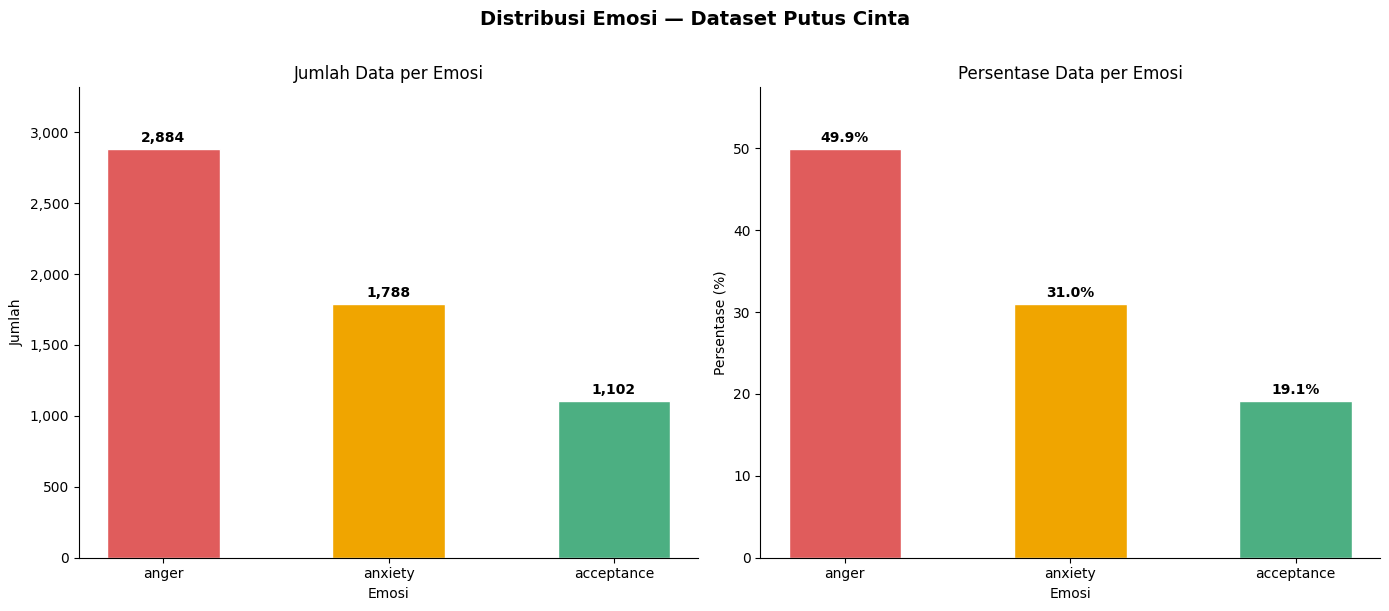

Visualisasi disimpan sebagai: 'distribusi_emosi.png'


In [27]:
# Visualisasi bar chart distribusi emosi
emotion_counts  = df_eda["predicted_emotion"].value_counts()
emotion_labels  = emotion_counts.index.tolist()
emotion_values  = emotion_counts.values.tolist()
emotion_colors  = {
    "anger"      : "#E05C5C",
    "anxiety"    : "#F0A500",
    "acceptance" : "#4CAF82"
}
bar_colors = [emotion_colors.get(e, "#888888") for e in emotion_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Distribusi Emosi — Dataset Putus Cinta", fontsize=14, fontweight="bold", y=1.01)

# --- Bar chart: jumlah ---
ax1 = axes[0]
bars = ax1.bar(emotion_labels, emotion_values, color=bar_colors, edgecolor="white", width=0.5)
ax1.set_title("Jumlah Data per Emosi", fontsize=12)
ax1.set_xlabel("Emosi")
ax1.set_ylabel("Jumlah")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, emotion_values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(emotion_values) * 0.01,
        f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax1.set_ylim(0, max(emotion_values) * 1.15)
ax1.spines[["top", "right"]].set_visible(False)

# --- Bar chart: persentase ---
ax2 = axes[1]
total          = sum(emotion_values)
emotion_pcts   = [v / total * 100 for v in emotion_values]
bars2 = ax2.bar(emotion_labels, emotion_pcts, color=bar_colors, edgecolor="white", width=0.5)
ax2.set_title("Persentase Data per Emosi", fontsize=12)
ax2.set_xlabel("Emosi")
ax2.set_ylabel("Persentase (%)")
for bar, pct in zip(bars2, emotion_pcts):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(emotion_pcts) * 0.01,
        f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax2.set_ylim(0, max(emotion_pcts) * 1.15)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("distribusi_emosi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi disimpan sebagai: 'distribusi_emosi.png'")

## Visualization (Word Cloud)

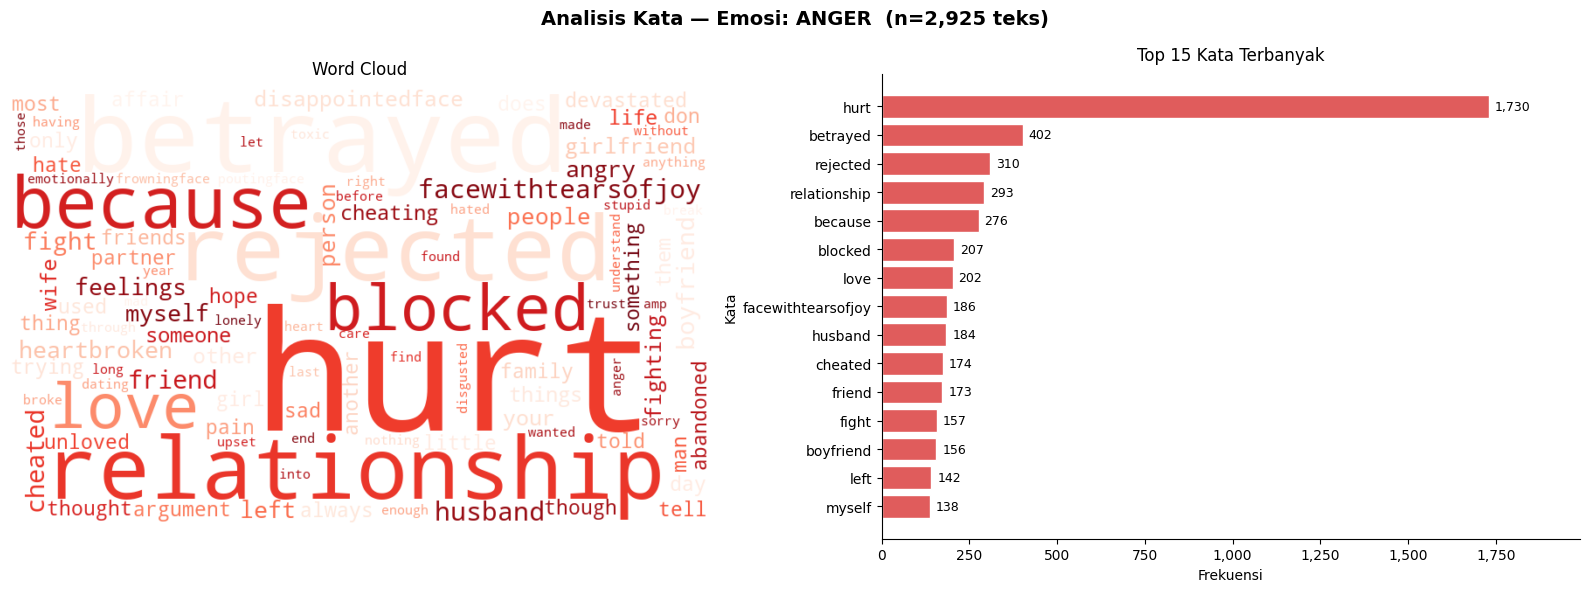

Disimpan sebagai: 'wordcloud_anger.png'


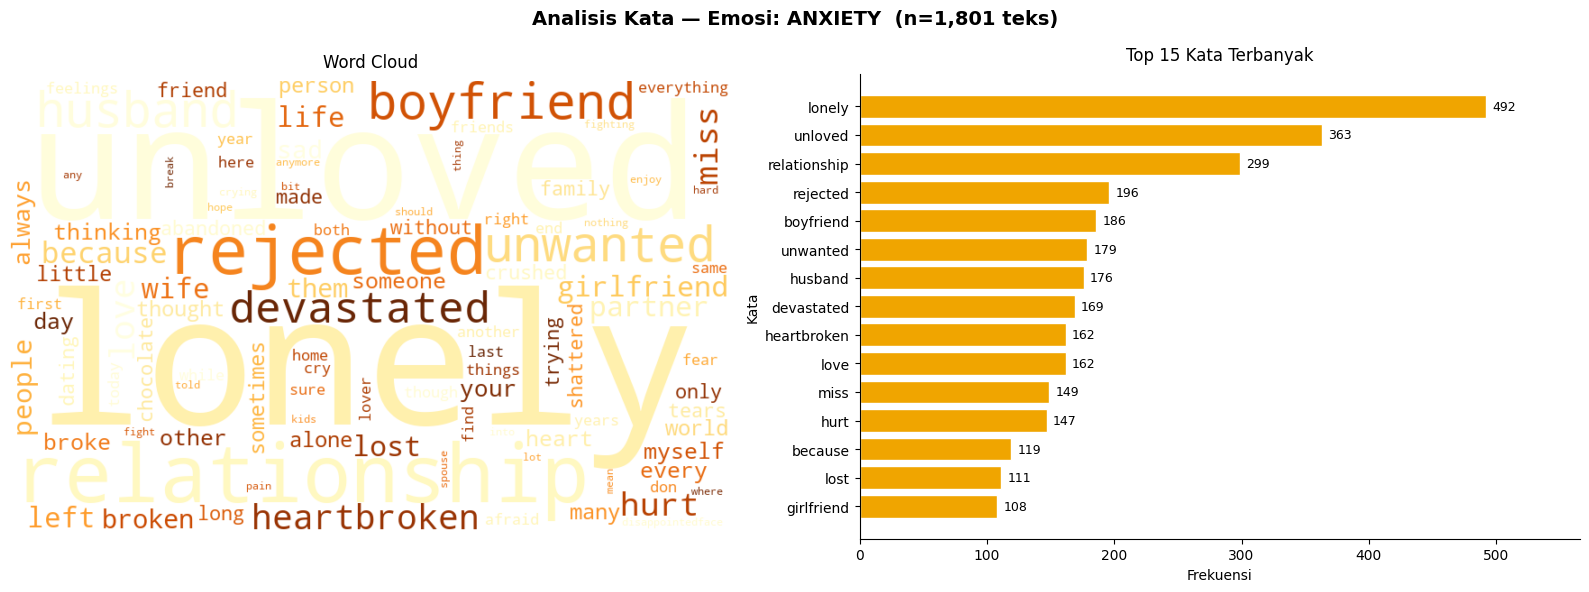

Disimpan sebagai: 'wordcloud_anxiety.png'


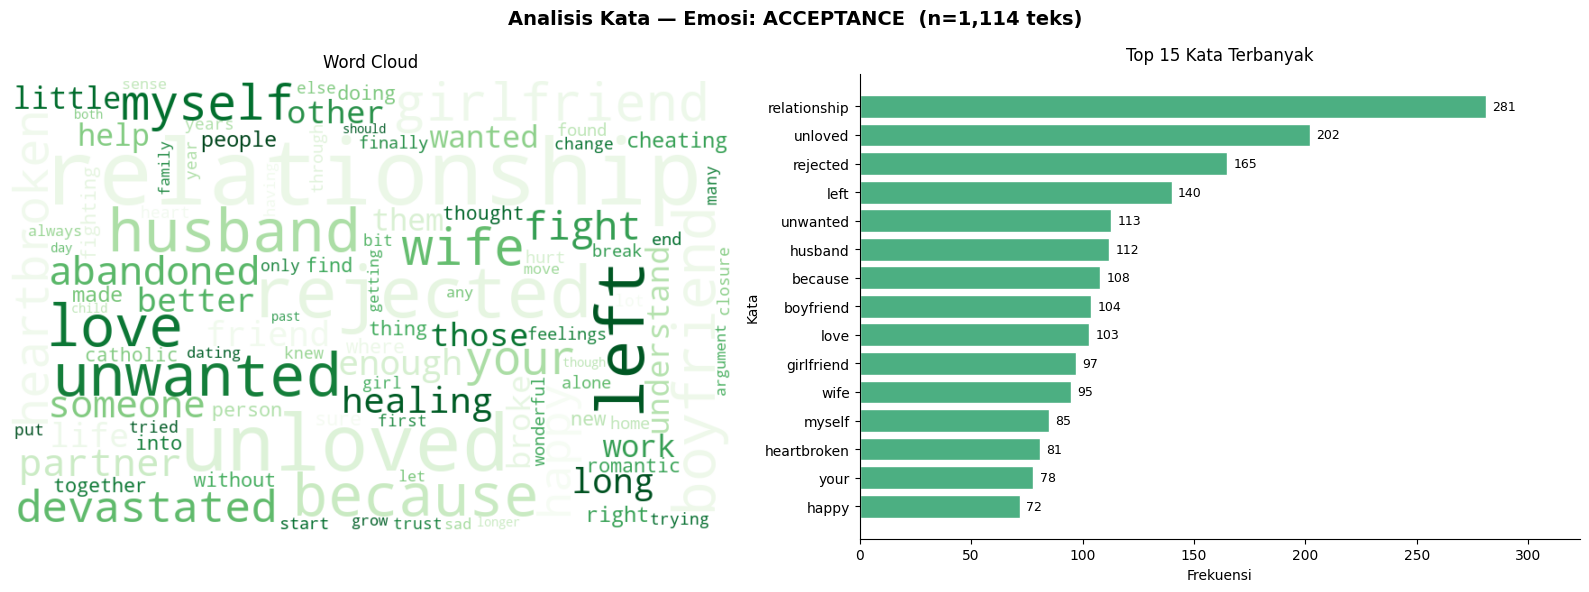

Disimpan sebagai: 'wordcloud_acceptance.png'


In [47]:
emotions      = ["anger", "anxiety", "acceptance"]
emotion_colors = {
    "anger"      : "#E05C5C",
    "anxiety"    : "#F0A500",
    "acceptance" : "#4CAF82",
}
wc_colors = {
    "anger"      : "Reds",
    "anxiety"    : "YlOrBr",
    "acceptance" : "Greens",
}
TOP_N = 15  # jumlah kata teratas di bar chart

for emotion in emotions:

    # ambil semua teks per emosi
    texts = df_eda[df_eda["predicted_emotion"] == emotion]["input_no_punct"]

    # gabungkan jadi satu string
    corpus = " ".join(texts.tolist())

    # hitung frekuensi token
    tokens     = corpus.split()
    token_freq = Counter(tokens)

    # hapus stopwords umum agar visualisasi lebih informatif
    stopwords = {
        "i", "me", "my", "he", "she", "we", "they", "you",
        "it", "is", "am", "are", "was", "were", "be", "been",
        "the", "a", "an", "and", "or", "but", "so", "if",
        "to", "of", "in", "on", "at", "for", "with", "about",
        "that", "this", "not", "no", "do", "did", "have",
        "has", "had", "will", "would", "can", "could", "just",
        "get", "got", "go", "going", "feel", "feeling", "felt",
        "know", "want", "need", "like", "make", "think",
        "really", "very", "so", "much", "more", "still",
        "him", "her", "his", "its", "our", "their", "us",
        "from", "when", "how", "what", "why", "who", "which",
        "there", "then", "than", "now", "back", "one", "all",
        "been", "being", "some", "even", "ever", "never",
        "time", "way", "out", "up", "down", "over", "after",
        "also", "well", "good", "bad", "too", "again", "away",
        "am", "said", "say", "see", "look", "come", "came",
    }

    token_freq_filtered = {
        word: freq
        for word, freq in token_freq.items()
        if word not in stopwords and len(word) > 2
    }

    # ---- layout: 1 baris, 2 kolom (wordcloud | bar chart) ----
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f"Analisis Kata — Emosi: {emotion.upper()}  "
        f"(n={len(texts):,} teks)",
        fontsize=14, fontweight="bold"
    )

    # --- Wordcloud ---
    ax_wc = axes[0]
    wc = WordCloud(
        width            = 800,
        height           = 500,
        background_color = "white",
        colormap         = wc_colors[emotion],
        max_words        = 100,
        stopwords        = stopwords,
        collocations     = False,
    ).generate_from_frequencies(token_freq_filtered)

    ax_wc.imshow(wc, interpolation="bilinear")
    ax_wc.axis("off")
    ax_wc.set_title("Word Cloud", fontsize=12, pad=10)

    # --- Bar chart top N kata ---
    ax_bar = axes[1]
    top_words  = sorted(
        token_freq_filtered.items(),
        key=lambda x: x[1],
        reverse=True
    )[:TOP_N]

    words  = [w for w, _ in top_words][::-1]   # balik agar terbesar di atas
    freqs  = [f for _, f in top_words][::-1]

    bars = ax_bar.barh(
        words, freqs,
        color     = emotion_colors[emotion],
        edgecolor = "white"
    )
    ax_bar.set_title(f"Top {TOP_N} Kata Terbanyak", fontsize=12, pad=10)
    ax_bar.set_xlabel("Frekuensi")
    ax_bar.set_ylabel("Kata")
    ax_bar.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    # label frekuensi di ujung bar
    for bar, freq in zip(bars, freqs):
        ax_bar.text(
            bar.get_width() + max(freqs) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{freq:,}", va="center", fontsize=9
        )
    ax_bar.set_xlim(0, max(freqs) * 1.15)
    ax_bar.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()

    filename = f"wordcloud_{emotion}.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Disimpan sebagai: '{filename}'")

# Export Dataset

In [48]:
final_cols = [
    "input_clean", "input_no_punct", "anger_prob", "anxiety_prob", "acceptance_prob",
    "predicted_emotion", "emotion_confidence"
]

output_filename = "Emotion Label Dataset.xlsx"
df_eda[final_cols].to_excel(output_filename, index=False)
print(f"\nDataset disimpan sebagai: '{output_filename}'")
print(f"Total baris : {len(df_eda):}")
print(f"Total kolom : {len(final_cols)}")


Dataset disimpan sebagai: 'Emotion Label Dataset.xlsx'
Total baris : 5840
Total kolom : 7


In [49]:
pd.read_excel("Emotion Label Dataset.xlsx")

,input_clean,input_no_punct,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence
0,i am feeling unloved and unwanted and as if th...,i am feeling unloved and unwanted and as if th...,0.211942,0.211942,0.576117,acceptance,0.576117
1,i am fighting with my mind trying to tell myse...,i am fighting with my mind trying to tell myse...,0.106507,0.786986,0.106507,anxiety,0.786986
2,i felt i won an argument afterwards i felt mys...,i felt i won an argument afterwards i felt mys...,0.211942,0.211942,0.576117,acceptance,0.576117
3,i felt as if i was fighting a battle that i wa...,i felt as if i was fighting a battle that i wa...,0.045279,0.045279,0.909443,acceptance,0.909443
4,i miss you i miss the chats but it is the any ...,i miss you i miss the chats but it is the any ...,0.114195,0.843795,0.042010,anxiety,0.843795
...,...,...,...,...,...,...,...
5835,even a single night of insomnia will ruin your...,even a single night of insomnia will ruin your...,0.576117,0.211942,0.211942,anger,0.576117
5836,i do not think my memory will fail me that muc...,i do not think my memory will fail me that muc...,0.576117,0.211942,0.211942,anger,0.576117
5837,a woman cheated on her husband for a shocking ...,a woman cheated on her husband for a shocking ...,0.909443,0.045279,0.045279,anger,0.909443
5838,britta it happened years ago i was sitting on ...,britta it happened years ago i was sitting on ...,0.106507,0.786986,0.106507,anxiety,0.786986


# Merge Dengan Emotion Emphathetic Counseling

## Import Dataset

In [51]:
df1 = pd.read_excel("Emotion Label Dataset.xlsx")
df1

,input_clean,input_no_punct,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence
0,i am feeling unloved and unwanted and as if th...,i am feeling unloved and unwanted and as if th...,0.211942,0.211942,0.576117,acceptance,0.576117
1,i am fighting with my mind trying to tell myse...,i am fighting with my mind trying to tell myse...,0.106507,0.786986,0.106507,anxiety,0.786986
2,i felt i won an argument afterwards i felt mys...,i felt i won an argument afterwards i felt mys...,0.211942,0.211942,0.576117,acceptance,0.576117
3,i felt as if i was fighting a battle that i wa...,i felt as if i was fighting a battle that i wa...,0.045279,0.045279,0.909443,acceptance,0.909443
4,i miss you i miss the chats but it is the any ...,i miss you i miss the chats but it is the any ...,0.114195,0.843795,0.042010,anxiety,0.843795
...,...,...,...,...,...,...,...
5835,even a single night of insomnia will ruin your...,even a single night of insomnia will ruin your...,0.576117,0.211942,0.211942,anger,0.576117
5836,i do not think my memory will fail me that muc...,i do not think my memory will fail me that muc...,0.576117,0.211942,0.211942,anger,0.576117
5837,a woman cheated on her husband for a shocking ...,a woman cheated on her husband for a shocking ...,0.909443,0.045279,0.045279,anger,0.909443
5838,britta it happened years ago i was sitting on ...,britta it happened years ago i was sitting on ...,0.106507,0.786986,0.106507,anxiety,0.786986


In [52]:
df2 = pd.read_excel("emotion_eda.xlsx")
df2

,input_clean,input_no_punct,breakup_score,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence,true_label
0,i am feeling unloved and unwanted and as if th...,i am feeling unloved and unwanted and as if th...,2,0.211942,0.211942,0.576117,acceptance,0.576117,sadness
1,i am fighting with my mind trying to tell myse...,i am fighting with my mind trying to tell myse...,2,0.106507,0.786986,0.106507,anxiety,0.786986,sadness
2,i felt i won an argument afterwards i felt mys...,i felt i won an argument afterwards i felt mys...,2,0.211942,0.211942,0.576117,acceptance,0.576117,anger
3,i felt as if i was fighting a battle that i wa...,i felt as if i was fighting a battle that i wa...,2,0.045279,0.045279,0.909443,acceptance,0.909443,joy
4,i miss you i miss the chats but it is the any ...,i miss you i miss the chats but it is the any ...,2,0.114195,0.843795,0.042010,anxiety,0.843795,joy
...,...,...,...,...,...,...,...,...,...
2187,"when my ex girlfriend cheated on me, i was so ...",when my ex girlfriend cheated on me i was so a...,4,0.964663,0.017668,0.017668,anger,0.964663,NaN
2188,"i cheated on my ex girlfriend, and i felt bad ...",i cheated on my ex girlfriend and i felt bad a...,4,0.786986,0.106507,0.106507,anger,0.786986,NaN
2189,when i was in high school there was a senior i...,when i was in high school there was a senior i...,2,0.327732,0.344535,0.327732,anxiety,0.344535,NaN
2190,i once called my girlfriend's mother mom by ac...,i once called my girlfriend s mother mom by ac...,2,0.327732,0.344535,0.327732,anxiety,0.344535,NaN


## Merge Emotion Dataset

In [53]:
required_cols = [
    "input_clean", "input_no_punct", "anger_prob", "anxiety_prob", "acceptance_prob",
    "predicted_emotion", "emotion_confidence"
]
df2_ready = df2[required_cols].copy()

print(f"Jumlah data df1 : {len(df1):} baris")
print(f"Jumlah data df2 : {len(df2_ready):} baris")

# gabungkan
df_merged = pd.concat([df1, df2_ready], ignore_index=True)

print(f"Jumlah sebelum dedup : {len(df_merged):} baris")

Jumlah data df1 : 5840 baris
Jumlah data df2 : 2192 baris
Jumlah sebelum dedup : 8032 baris


In [55]:
# cek teks terduplikat
dupes = df_merged[df_merged.duplicated(subset=["input_clean"], keep=False)].copy()
dupes_sorted = dupes.sort_values("input_clean")

print(f"Total baris yang terduplikat : {len(dupes):,}")
print(f"Jumlah teks unik yang duplikat: {dupes['input_clean'].nunique():,}")

print("\nTeks yang terduplikat:")
print(dupes_sorted["input_clean"].head(20).to_string())

Total baris yang terduplikat : 3,202
Jumlah teks unik yang duplikat: 1,573

Teks yang terduplikat:
7565    a boy phoned me at night and wanted to talk to...
1488    a boy phoned me at night and wanted to talk to...
3365    a boy phoned me at night and wanted to talk to...
650     a boyfriend with whom i split up with came ove...
6593    a boyfriend with whom i split up with came ove...
2364    a boyfriend with whom i split up with came ove...
2429    a friend of mine was drunk and having an argum...
4759    a friend of mine was drunk and having an argum...
4334    a friend of mine was hurt as he thought that o...
2392    a friend of mine was hurt as he thought that o...
6636    a friend of mine was hurt as he thought that o...
689     a friend of mine was hurt as he thought that o...
101     a letter from my boyfriend began in such a way...
5963    a letter from my boyfriend began in such a way...
2365    a letter from my boyfriend began in such a way...
3471    a letter from my boyfri

## Hapus Duplikat

In [57]:
# hapus duplikat berdasarkan "input_clean"
df_merged = df_merged.drop_duplicates(subset=["input_clean"]).reset_index(drop=True)

print(f"Jumlah setelah dedup : {len(df_merged):} baris")
print(f"Dihapus              : {len(df1) + len(df2_ready) - len(df_merged):,} baris")

# cek distribusi predicted emotion hasil merge
print("\nDistribusi Predicted Emotion:")
print(df_merged["predicted_emotion"].value_counts().to_string())

Jumlah setelah dedup : 6403 baris
Dihapus              : 1,629 baris

Distribusi Predicted Emotion:
predicted_emotion
anger         3028
anxiety       2260
acceptance    1115


## Export Data Merge

In [58]:
# export
df_merged.to_excel("Emotion Dataset Merged.xlsx", index=False)
print("\nDataset merged disimpan sebagai: 'Emotion Dataset Merged.xlsx'")


Dataset merged disimpan sebagai: 'Emotion Dataset Merged.xlsx'
